# BACKGROUND



## Statement



This project analyzes Ho/Er multilayers, where
different Ho layer thicknesses induce temperature-dependent conical and helical magnetic
phases and an exchange-bias shift.

The analysis will use SQUID magnetometry data: samples S16 (Ho₇|Er₂₁),
 measured under varying magnetic fields and temperatures. Four datasets (M–T–H and M–
H–T for both samples) record how magnetization changes with temperature and field under
zero-field-cooled (ZFC) and field-cooled (FC) conditions

Manual interpretation of multi-file SQUID data is slow and error-prone, so this project will
develop an automated, auditable workflow in Notebook that:

(1) Imports and cleans raw ASCII data by parsing headers, units, removing background signals
(paramagnetic or diamagnetic artifacts).

(2) Extracts coercivity, remanence, and exchange-bias (Hₑᵦ) values.  

(3) Visualizes field-dependent (M–H) and temperature-dependent (M–T) curves to reveal phase
transitions and spin reorientation behavior.

This workflow will streamline quantitative analysis and provide a transparent,
auditable method for studying magnetic coupling in RE multilayers.

LLM (ChatGPT) is used to refine this Notebook.

## Prior Work

1. **Huang et al., *J. Magn. Magn. Mater.* **585**, 171108 (2023)**  
   **Content**: Demonstrates exchange bias in Er/Tb multilayers occurring below 20 K, attributed to spin imbalance within the Er conical magnetic phase. The study quantifies irreversible spin populations at the Er/Tb interface.  
   **Relevance**: Provides a foundation for understanding how conical phases in rare-earth multilayers generate exchange bias. The RKKY coupling model and empirical irreversible spin counting method inform parameter extraction strategies for analyzing Ho/Er interface effects in this project.

2. **Xiao et al., *Phys. Rev. B* **109**, 174422 (2024)**  
   **Content**: Investigates exchange bias in Ho/Tb multilayers, identifying sublattice disorder within the Ho conical phase as the primary mechanism. Uses an n-vector mean-field Hamiltonian to model temperature-dependent bias and validates with Curie-Weiss fits to susceptibility data.  
   **Relevance**: Directly applicable to Ho/Er systems studied here. The mean-field modeling approach and Curie-Weiss analysis provide templates for hypothesis testing in step (4) of the workflow. The focus on Ho layer thickness dependence guides comparison between S16 and S17 samples.

3. **Xiao et al., *Appl. Phys. Lett.* **124**, 142401 (2024)**  
   **Content**: Reports spin-flop transitions in Er/Ho thin films using field-dependent magnetometry. Develops a phenomenological free-energy model (Eq. 1 in that paper) incorporating both uniaxial and basal-plane anisotropy to explain field-induced phase changes.  
   **Relevance**: The free-energy framework is essential for interpreting M–H loop shapes and field-induced transitions observed in this project's data. Anisotropy parameters extracted from fits can be compared to predicted values from this model to assess adequacy.

4. **Huang et al., *Sci. Rep.* **12**, 21836 (2022)**  
   **Content**: Explores indirect magnetic coupling in Mn₃Ir/CoFe/Dy trilayers through helicity inversion of the antiferromagnetic order. Models coupling via antiferromagnetic sublattice imbalance propagated through RKKY interactions across spacer layers.  
   **Relevance**: While focusing on different materials, the RKKY propagation mechanism and sublattice imbalance framework are conceptually transferable to Ho/Er interfaces. Demonstrates how interfacial disorder can couple through non-magnetic spacers, informing interpretation of long-range coupling effects.

5. **Xiao et al., *Phys. Rev. B* **109**, 224403 (2024)**  
   **Content**: **Primary benchmark for this project.** Reports exchange bias in Ho/Er multilayers arising from conical-phase disorder, using the exact samples (S16, S17) analyzed here. Presents spin-imbalance model (Eq. 1) relating bias field to irreversible spin density, and validates via remanence peak analysis and temperature-dependent M–H measurements.  
   **Relevance**: This is the reference paper whose results will be reproduced and validated. The automated workflow developed here aims to replicate their parameter extraction (Hc, Mr, Heb) and model fits, while improving reproducibility and enabling hypothesis testing through statistical rigor. Comparison with their published values provides validation of the analysis pipeline.

## Approach to Analysis

**1. Data Import and File Parsing**

Download raw measurement files from the GitHub repository. These files contain both experimental metadata (sample information, measurement conditions) and numerical data. The workflow automatically separates and organizes this information into structured data tables for analysis.

**2. Analyzing Field-Dependent Data (M–H Hysteresis Loops)**

Examine how magnetization responds as the magnetic field sweeps back and forth at various temperatures. The workflow groups measurements by temperature, removes unwanted background signals from the sample holder, extracts key magnetic properties (coercivity, remanence, exchange bias, saturation), and generates multi-panel visualizations showing how magnetic behavior evolves with temperature.

**Overall Goal**: Create a transparent, automated analysis pipeline that reproduces published results.

# LOAD LIBRARIES

## Library Comments

- **`requests`**  
  Downloads raw `.dat` files directly from GitHub URLs.  
  [Documentation](https://docs.python-requests.org/en/latest/)

- **`io.StringIO`**  
  Converts downloaded string content into a file-like object for in-memory parsing with `pandas`.

- **`pandas`**  
  Parses, cleans, and structures data into DataFrames; enables grouping, splitting, and metadata storage.  
  [Documentation](https://pandas.pydata.org/docs/)

- **`numpy`**  
  Handles numerical arrays, supports interpolation, statistical analysis, and error propagation.  
  [Documentation](https://numpy.org/doc/)

- **`matplotlib.pyplot`**  
  Generates all static plots: M–H loops, M–T curves, and parameter trends.  
  [Documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.html)

- **`collections.defaultdict`**  
  Organizes metadata key-value pairs during header parsing.

- **`re`**  
  Uses regex to extract long names and units from column headers (e.g., `"Moment (emu)"`).

- **`math`**  
  Provides basic math functions (e.g., `sqrt`, `exp`) for calculations.

- **`scipy`**  
  Performs linear/nonlinear fitting, peak detection, interpolation, and statistical tests (χ², t-test).  
  [Documentation](https://scipy.org/)

## Code Block

In [58]:
import requests                     # Downloads raw .dat files from GitHub URLs
                                    # [https://docs.python-requests.org/en/latest/]
from io import StringIO             # Converts downloaded string to file-like object for pandas
import pandas as pd                 # Parses, cleans, structures data into DataFrames; enables grouping/splitting
                                    # [https://pandas.pydata.org/docs/]
import numpy as np                   # Numerical arrays, interpolation, stats, error propagation
                                    # [https://numpy.org/doc/]
import re                           # Regex to extract long names and units from column headers (e.g., "Moment (emu)")
from collections import defaultdict  # Organizes metadata key-value pairs during header parsing
import math                         # Basic math functions (sqrt, exp) for calculations

# Visualization
import matplotlib.pyplot as plt     # Generates static plots: M-H loops, M-T curves, parameter trends
                                    # [https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.html]

import os                           # File system operations for exporting data

def export_plot_data(df, filename_base, export_dir='plot_data_exports'):
    """
    Exports the provided DataFrame to a CSV file.
    
    Args:
        df (pd.DataFrame): The data to export.
        filename_base (str): The base name for the file (without extension).
        export_dir (str): The directory to save the file in.
    """
    if not os.path.exists(export_dir):
        os.makedirs(export_dir)
    
    # Sanitize filename
    safe_filename = "".join([c if c.isalnum() or c in ('_', '-') else '_' for c in filename_base])
    filename = f"{safe_filename}.csv"
    filepath = os.path.join(export_dir, filename)
    
    try:
        df.to_csv(filepath, index=False)
        print(f"Data exported to: {filepath}")
    except Exception as e:
        print(f"Failed to export data: {e}")


# IMPORT DATA

Data are imported in this section from GitHub (to enable evaluation by the instructor and class members).

**Class assignments** related to the building of this section include:
*   Data file formatting
*   Loading data

### Raw Data Sources
- **SQUID MPMS3 `.dat` files** (M–H and M–T measurements):  
  Hosted on GitHub:  
  [https://github.com/ZuomingWang/SuperconductingQuantumInterferenceDeviceProcessor](https://github.com/ZuomingWang/SuperconductingQuantumInterferenceDeviceProcessor)  
  Files used:  
  - `S16-M-H_T.dat`, `S16-M-T_H.dat`  
  - `S17-M-H_T.dat`, `S17-M-T_H.dat`

## Data Import Code

Total header rows: 38
Total data rows: 5591
Sample header entries:
  ; MPMS3 Data File (default extension .dat)
  ; Copyright (c) 2007, Quantum Design, Inc. All rights reserved.
  TITLE,
  FILEOPENTIME,3884591358.92161,02/03/2023,1:09 pm
  BYAPP,MPMS3 w/ AC,1.0,1.1
  INFO,MPMS3 Measurement Release 1.1.16 Build 424, MultiVu Release 2.3.4.19,APPNAME
=== Data Columns ===
Chosen columns: Temperature (K), Magnetic Field (Oe), Moment (emu), M. Std. Err. (emu)
First 3 rows of data:


,Temperature (K),Magnetic Field (Oe),Moment (emu),M. Std. Err. (emu)
0,1.999925,70000.359375,0.003740,1.467504e-06
1,1.999831,60000.210938,0.003855,1.819988e-06
2,2.000293,50000.269531,0.003958,8.128455e-07


=== Key Metadata ===
Device: superconducting quantum interference device (SQUID) magnetometer from Quantum Design (MPMS3)
Sample material: Nb-Y-[Ho8-Er6]_10-TaN
Sample holder: Quartz
Sample offset (mm): 67


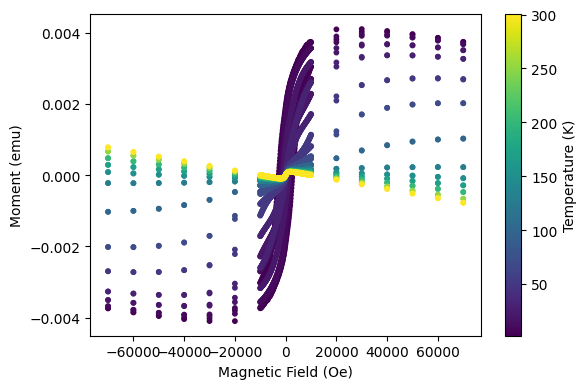

In [59]:
# URL of the raw data file on GitHub
github_url = 'https://raw.githubusercontent.com/ZuomingWang/SuperconductingQuantumInterferenceDeviceProcessor/refs/heads/main/S16-M-H_T.dat'

# Download the file
response = requests.get(github_url)
response.raise_for_status() # Raise an exception for bad status codes

# Read the raw file sections from the downloaded content
raw_lines = response.text.splitlines()

header_idx = raw_lines.index('[Header]') + 1
data_idx = raw_lines.index('[Data]')
header_lines = raw_lines[header_idx:data_idx]
data_lines = raw_lines[data_idx + 1:]

print(f'Total header rows: {len(header_lines)}')
print(f'Total data rows: {len(data_lines)}')
print('Sample header entries:')
for line in header_lines[:6]:
    print('  ' + line)

# Parse metadata entries

def parse_header_line(line: str):
    if not line or line.startswith(';'):
        return None
    tokens = [segment.strip() for segment in line.split(',')]
    prefix = tokens[0]
    if prefix == 'INFO' and len(tokens) >= 2:
        key = tokens[-1]
        value_tokens = tokens[1:-1]
    else:
        key = prefix
        value_tokens = tokens[1:]
    raw_values = [value for value in value_tokens]
    cleaned = [value for value in value_tokens if value]
    parsed_value = None
    if cleaned:
        parsed_value = cleaned[0] if len(cleaned) == 1 else cleaned
    return key, raw_values, parsed_value

metadata_rows = []
metadata_map = defaultdict(list)

for line in header_lines:
    parsed = parse_header_line(line)
    if not parsed:
        continue
    key, raw_values, parsed_value = parsed
    metadata_rows.append({'Key': key, 'Raw Values': raw_values, 'Parsed Value': parsed_value})
    metadata_map[key].append(parsed_value)

metadata_df = pd.DataFrame(metadata_rows)
metadata = {
    key: values[0] if len(values) == 1 else values
    for key, values in metadata_map.items()
}

# Build the M-H data frame

data_df = pd.read_csv(StringIO('\n'.join(data_lines)))
mh_columns = ['Temperature (K)', 'Magnetic Field (Oe)', 'Moment (emu)']
if 'M. Std. Err. (emu)' in data_df.columns:
    mh_columns.append('M. Std. Err. (emu)')

mh_df = data_df[mh_columns].copy()

print('=== Data Columns ===')
print(f'Chosen columns: {", ".join(mh_columns)}')
print(f'First 3 rows of data:')
display(mh_df.head(3))

# Split long name and units

column_labels = data_lines[0].split(',')
pattern = re.compile(r'^(.*?)(?:\s*\((.*)\))?$')

column_metadata = []
for label in column_labels:
    text = label.strip()
    match = pattern.match(text)
    long_name = match.group(1).strip() if match else text
    unit = match.group(2).strip() if match and match.group(2) else None
    column_metadata.append({'Original Label': text, 'Long Name': long_name, 'Unit': unit})

column_meta_df = pd.DataFrame(column_metadata)

# Summarize and display key metadata
print('=== Key Metadata ===')
metadata_display = {
    'Device': 'superconducting quantum interference device (SQUID) magnetometer from Quantum Design (MPMS3)',
    'Sample material': metadata.get('SAMPLE_MATERIAL'),
    'Sample holder': metadata.get('SAMPLE_HOLDER'),
    'Sample offset (mm)': metadata.get('SAMPLE_OFFSET'),
}

for key, value in metadata_display.items():
    print(f'{key}: {value}')

# visualize the M-H curves

fig, ax = plt.subplots(figsize=(6, 4))
scatter = ax.scatter(
    mh_df['Magnetic Field (Oe)'],
    mh_df['Moment (emu)'],
    c=mh_df['Temperature (K)'],
    s=10,
    cmap='viridis'
)

ax.set_xlabel('Magnetic Field (Oe)')
ax.set_ylabel('Moment (emu)')
cbar = fig.colorbar(scatter, ax=ax, label='Temperature (K)')
plt.tight_layout()
plt.show()

In [60]:
# Export the data used for this plot
# export_plot_data(mh_df, 'initial_raw_MH_data')

## Sticking Points

### Challenge 1: Determining Rows per Temperature Set

**Problem**: Raw data stacks multiple temperature measurements without explicit delimiters. Automated change-point detection failed due to gradual temperature stabilization between sets.

**Solution**: Manual inspection revealed each temperature set contains exactly 430 points (one complete field sweep). Validated by confirming equal row counts and constant temperature within each set. This fixed-count approach proved more reliable than algorithmic detection for this instrument protocol.

### Challenge 2: Selecting Linear Region for Background Subtraction

**Problem**: Determining which high-field points to use for linear fits was non-trivial. Too many points include sample contributions; too few yield unstable fits. Asymmetry between loop branches added complexity.

**Solution**: Implemented adaptive validation (see code in cell 21):
- Test left and right ends independently (5 extreme points)
- Reject if |slope| > 0.001 emu/Oe
- Reduce to 2-3 points if initial fit fails
- Fallback to 95th percentile quantile if both ends fail

One-size-fits-all corrections fail for temperature-dependent systems; adaptive fitting ensures physically reasonable results.

### Challenge 3: Handling Inconsistent Metadata Formatting

**Problem**: The 36-line header has inconsistent formatting (mixed delimiters, "INFO" prefixes, empty fields). Direct parsing caused crashes.

**Solution**: Built robust parser (`parse_header_line` in cell 16) that handles multiple formats, skips comments, returns None for unparseable lines, and uses defaultdict for duplicate keys. Defensive programming essential for real experimental data.

### Challenge 4: Extracting Coercivity from Zero-Crossings (Anticipated)

**Problem**: Coercivity requires finding zero-crossings of corrected moment, complicated by measurement noise, non-uniform field spacing, and occasional loop artifacts.

**Plan**: Use scipy interpolation to separate ascending/descending branches, apply local smoothing near zero, calculate Hc as average of |H₊| and |H₋|, and report uncertainty from interpolation error. **Not yet implemented.**

## Description of Approach

# DATA CONDITIONING AND EXPLORATION



## Data Cleaning and Conditioning

## Improved Uncertainty Propagation Methodology

The parameters ($H_c, M_r, H_{eb}$) in the plots below are extracted using a **local polynomial fitting** approach, which is more robust to noise than simple linear interpolation.

**1. Coercivity ($H_c$) & Exchange Bias ($H_{eb}$)**
- **Method**: A local quadratic polynomial $H(M) = a + bM + cM^2$ is fitted to data points near $M=0$ for both ascending and descending branches.
- **Extraction**: The zero-crossing field is the intercept parameter $a$ (since we fit $H$ vs $M$).
- **Uncertainty**: The standard error of the intercept parameter $a$ is derived directly from the covariance matrix of the least-squares fit ($\sqrt{Cov_{aa}}$). This naturally accounts for local scatter and noise density.

**2. Remanence ($M_r$)**
- **Method**: A local quadratic polynomial $M(H) = a + bH + cH^2$ is fitted to data points near $H=0$ for both branches.
- **Extraction**: The remanence is the intercept parameter $a$ (moment at zero field).
- **Uncertainty**: Similarly, the standard error of $a$ from the fit covariance matrix is used.

**3. Saturation Magnetization ($M_s$)**
- **Method**: Mean of absolute moments for $|H| > 60000$ Oe.
- **Uncertainty**: Standard Error of the Mean (SEM) of the high-field moments.


In [61]:
# Define function to visualize M-H loops by temperature sets

def plot_mh_sets(groups, y_col, title, x_column='Magnetic Field (Oe)', export_csv=False):
    n = len(groups)
    cols = 3
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3), sharex=True)
    axes = axes.flatten()
    for ax, (label, frame) in zip(axes, groups.items()):
        ax.plot(frame[x_column], frame[y_col], marker='o', markersize=2, linewidth=0.8)
        ax.set_title(label)
        ax.set_xlabel('Magnetic Field (Oe)')
        ax.set_ylabel(y_col)
        
        # Export individual set data if requested
        if export_csv:
            export_plot_data(frame, f"{title}_{label}")
    for ax in axes[n:]:
        ax.axis('off')
    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    fig.subplots_adjust(top=0.92)
    plt.show()

In [62]:
# Build the M-H data frame and extract column information

data_df = pd.read_csv(StringIO('\n'.join(data_lines)))
mh_columns = ['Temperature (K)', 'Magnetic Field (Oe)', 'Moment (emu)']
if 'M. Std. Err. (emu)' in data_df.columns:
    mh_columns.append('M. Std. Err. (emu)')

mh_df = data_df[mh_columns].copy()

print('=== Data Columns ===')
print(f'Chosen columns: {", ".join(mh_columns)}')
print(f'First 3 rows of data:')
display(mh_df.head(3))

=== Data Columns ===
Chosen columns: Temperature (K), Magnetic Field (Oe), Moment (emu), M. Std. Err. (emu)
First 3 rows of data:


,Temperature (K),Magnetic Field (Oe),Moment (emu),M. Std. Err. (emu)
0,1.999925,70000.359375,0.003740,1.467504e-06
1,1.999831,60000.210938,0.003855,1.819988e-06
2,2.000293,50000.269531,0.003958,8.128455e-07


In [63]:
# Choose the magnetic field axis and moment column
x_column = 'Magnetic Field (Oe)'
moment_column = 'Moment (emu)'
print(f'X axis: {x_column}')
print(f'Y axis: {moment_column}')

X axis: Magnetic Field (Oe)
Y axis: Moment (emu)


In [64]:
# Determine rows per temperature set and split data

rows_per_set = 430
num_sets, remainder = divmod(len(data_df), rows_per_set)
if remainder:
    raise ValueError(f'Expected whole number of sets; leftover rows = {remainder}')

set_ids = np.repeat(np.arange(num_sets), rows_per_set)
data_df = data_df.copy()
data_df['Set ID'] = set_ids
data_df['Set Row'] = data_df.groupby('Set ID').cumcount()
set_summary = (
    data_df.groupby('Set ID').agg(
        rows=('Set Row', 'count'),
        temperature_K=('Temperature (K)', 'mean')
    ).reset_index()
)

# Create the 'Set Label' column and merge it into data_df
set_summary['Set Label'] = set_summary['temperature_K'].round().astype(int).astype(str) + 'K'
data_df = data_df.merge(set_summary[['Set ID', 'Set Label']], on='Set ID', how='left')

print(f'Detected {len(set_summary)} temperature sets, {rows_per_set} rows each.')
display(set_summary[['Set ID', 'rows', 'temperature_K', 'Set Label']])

Detected 13 temperature sets, 430 rows each.


,Set ID,rows,temperature_K,Set Label
0,0,430,1.999984,2K
1,1,430,9.999935,10K
2,2,430,19.999870,20K
3,3,430,29.999962,30K
4,4,430,50.000056,50K
5,5,430,70.000125,70K
6,6,430,100.000212,100K
7,7,430,130.000451,130K
8,8,430,150.000453,150K
9,9,430,170.001312,170K


In [65]:
# Add working columns for background correction
data_df['Background Moment (emu)'] = 0.0
data_df['Corrected Moment (emu)'] = data_df[moment_column]

# Group and sort by temperature (extract numeric value from label like "5K" → 5)
temperature_groups = {label: frame.copy().reset_index(drop=True)
                     for label, frame in sorted(data_df.groupby('Set Label'),
                                               key=lambda x: float(x[0].replace('K', '')))}
# print(f'Prepared {len(temperature_groups)} per-temperature data tables.')
# list(temperature_groups.keys())

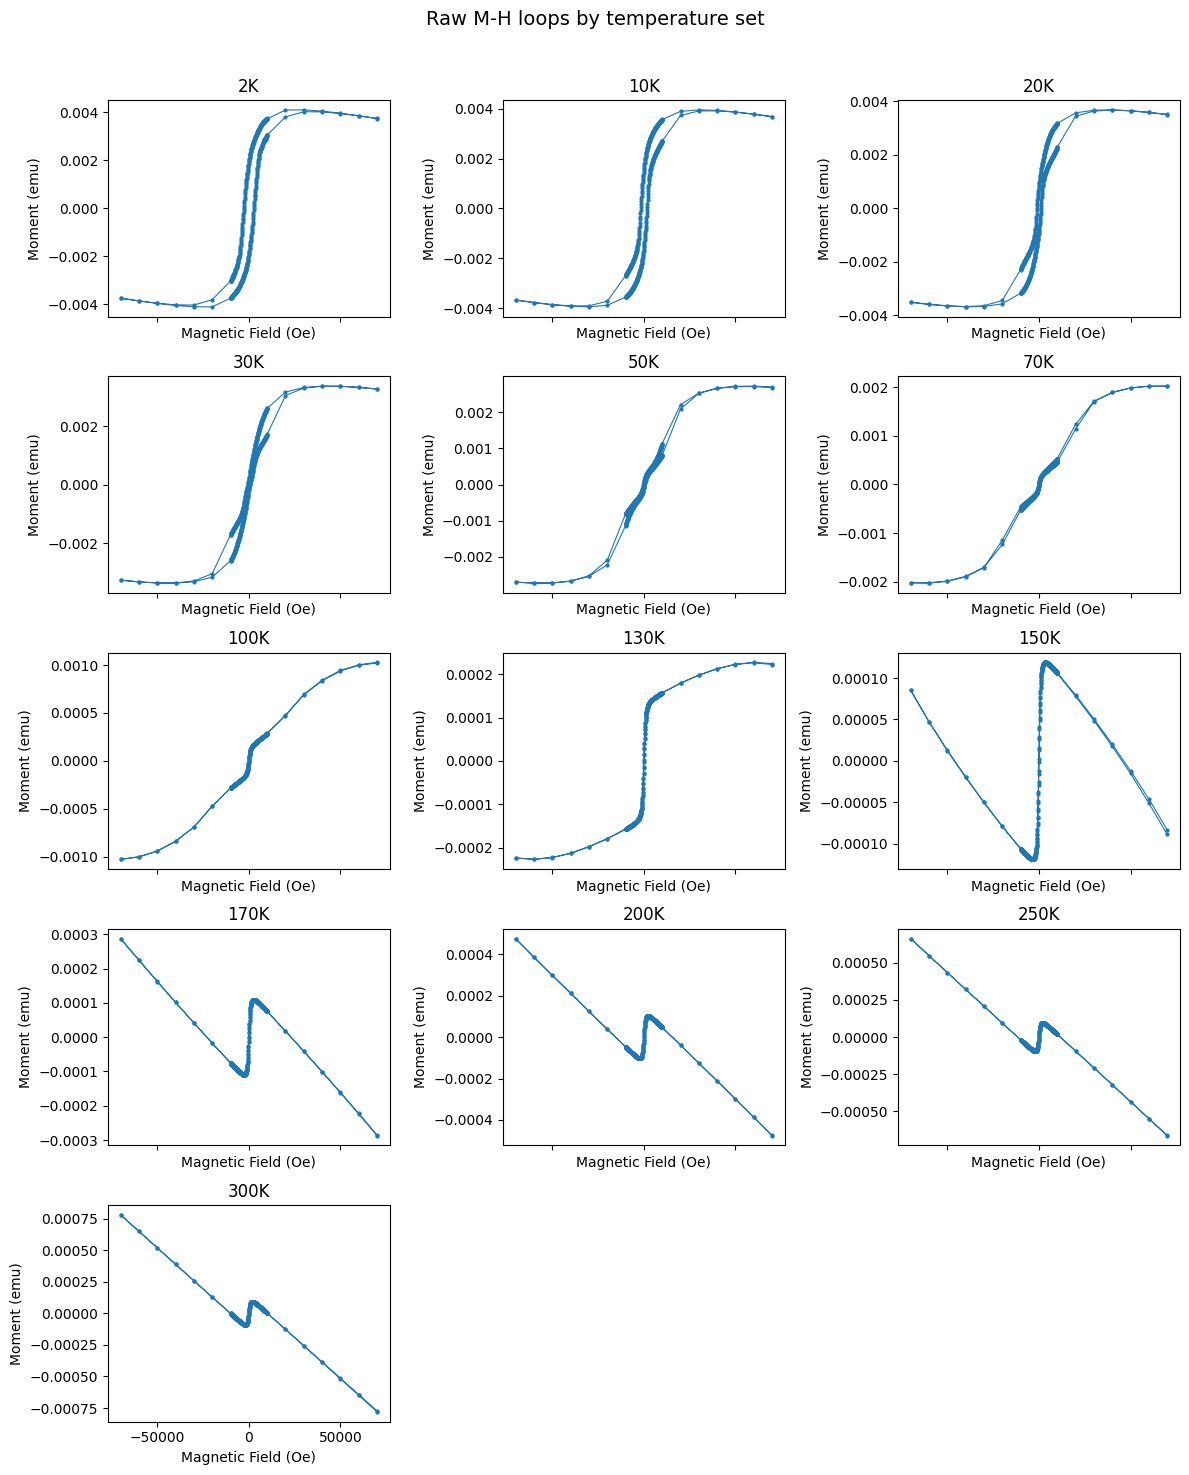

In [66]:
# Visualize raw M-H loops by temperature set
plot_mh_sets(temperature_groups, moment_column, 'Raw M-H loops by temperature set', export_csv=False)
# plot_mh_sets(temperature_groups, moment_column, 'Raw M-H loops by temperature set', export_csv=True)

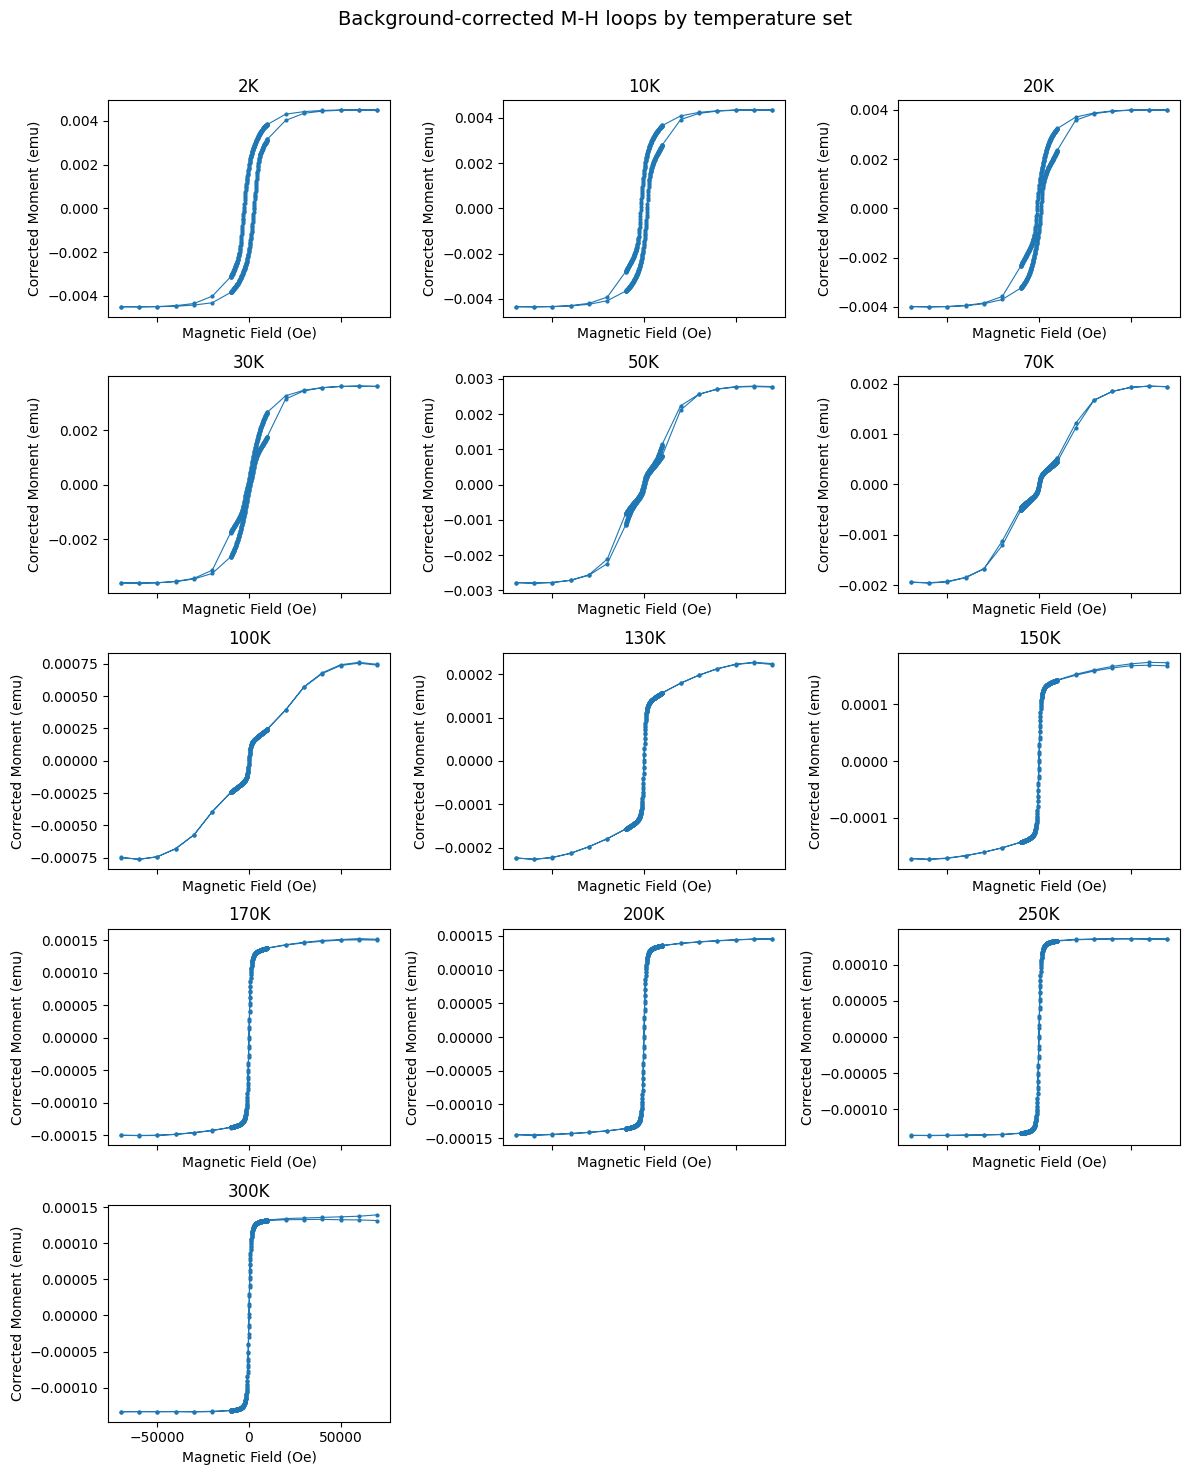

In [67]:
# Linear background correction per temperature set

min_points = 2
max_points = 5
acceptable_slope_range = (-0.001, 0.001)
fit_records = []

for set_id, frame in data_df.groupby('Set ID'):
    label = frame['Set Label'].iat[0]
    temperature = label

    # Sort by magnetic field to locate ends
    sorted_frame = frame.sort_values(x_column)

    # Select the most left and most right points
    left_end = sorted_frame.iloc[:max_points]
    right_end = sorted_frame.iloc[-max_points:]

    best_slope, best_intercept, best_points, best_region = 0.0, 0.0, 0, None

    for end_data, region_name in [(left_end, 'left end'), (right_end, 'right end')]:
        if len(end_data) >= min_points:
            slope, intercept = np.polyfit(end_data[x_column], end_data[moment_column], 1)
            points_used = len(end_data)

            if acceptable_slope_range[0] <= slope <= acceptable_slope_range[1]:
                if points_used > best_points:
                    best_slope, best_intercept, best_points, best_region = slope, intercept, points_used, region_name
            else:
                if points_used > min_points * 2:
                    half_points = max(min_points, points_used // 2)
                    if region_name == 'left end':
                        reduced_data = left_end.iloc[:half_points]
                    else:
                        reduced_data = right_end.iloc[-half_points:]
                    slope_reduced, intercept_reduced = np.polyfit(reduced_data[x_column], reduced_data[moment_column], 1)
                    points_reduced = len(reduced_data)
                    if acceptable_slope_range[0] <= slope_reduced <= acceptable_slope_range[1]:
                        print(f"Set {set_id}, {region_name}: Slope={slope_reduced:.2e}, Points={points_reduced} (Reduced and Accepted)")
                        if points_reduced > best_points:
                            best_slope, best_intercept, best_points, best_region = slope_reduced, intercept_reduced, points_reduced, region_name
                    else:
                        print(f"Set {set_id}, {region_name}: Slope={slope:.2e} out of range, reduction failed")

    # Use the best fit from either end
    if best_points > 0:
        slope, intercept = best_slope, best_intercept
    else:
        quantile_threshold = frame[x_column].abs().quantile(0.95)
        linear_data = frame[frame[x_column].abs() >= quantile_threshold].head(max_points)
        if len(linear_data) >= min_points:
            slope, intercept = np.polyfit(linear_data[x_column], linear_data[moment_column], 1)
            best_points = len(linear_data)
            print(f"Set {set_id}: Fallback High-field, Slope={slope:.2e}, Points={best_points}")
        else:
            slope, intercept = 0.0, 0.0
            best_points = 0
            print(f"Set {set_id}: No valid region found")

    # Apply correction
    frame_index = frame.index
    background_moment = slope * frame[x_column]
    data_df.loc[frame_index, 'Background Moment (emu)'] = background_moment
    data_df.loc[frame_index, 'Corrected Moment (emu)'] = frame[moment_column] - background_moment

    if 'Comments' not in data_df.columns:
        data_df['Comments'] = ''
    data_df.loc[frame_index, 'Comments'] = temperature

    fit_records.append({
        'Set ID': set_id,
        'Set Label': label,
        'Slope (emu/Oe)': slope,
        'Intercept (emu)': intercept,
        'Points used': best_points,
        'Region': best_region if best_points > 0 else 'High-field fallback'
    })

fit_results_df = pd.DataFrame(fit_records)

# Recreate temperature_groups with corrected data, sorted by temperature
temperature_groups = {label: frame.copy().reset_index(drop=True)
                     for label, frame in sorted(data_df.groupby('Set Label'),
                                               key=lambda x: float(x[0].replace('K', '')))}

# Visualize corrected M-H loops by temperature set
plot_mh_sets(temperature_groups, 'Corrected Moment (emu)', 'Background-corrected M-H loops by temperature set', export_csv=False)
# plot_mh_sets(temperature_groups, 'Corrected Moment (emu)', 'Background-corrected M-H loops by temperature set', export_csv=True)

In [68]:
# Export the corrected data for all temperature sets
# for label, frame in temperature_groups.items():
#     export_plot_data(frame, f'Background-corrected_MH_loops_by_temperature_set_{label}')

## Data Exploration and Visualization

In [69]:
# Data Preparation for Parameter Extraction

from scipy.interpolate import interp1d

# Recreate temperature_groups from the corrected data_df
temperature_groups = {label: frame.copy().reset_index(drop=True)
                     for label, frame in data_df.groupby('Set Label')}
print(f'Loaded {len(temperature_groups)} corrected temperature datasets for parameter extraction.\n')

Loaded 13 corrected temperature datasets for parameter extraction.



In [70]:
# Helper Functions: Branch Separation and Zero Crossing Detection

def separate_branches(field, moment, moment_err=None):
    """
    Separate M-H loop into ascending and descending branches.
    
    Automatically detects whether the loop starts from max or min field.
    Also separates error arrays if provided.
    """
    # Check if first point is closer to max or min field
    field_max = np.max(field)
    field_min = np.min(field)
    
    if abs(field[0] - field_max) < abs(field[0] - field_min):
        # Data starts from maximum field, find minimum as turning point
        turning_idx = np.argmin(field)
        desc_field = field[:turning_idx+1]
        desc_moment = moment[:turning_idx+1]
        asc_field = field[turning_idx:]
        asc_moment = moment[turning_idx:]
        
        if moment_err is not None:
            desc_err = moment_err[:turning_idx+1]
            asc_err = moment_err[turning_idx:]
        else:
            desc_err = None
            asc_err = None
    else:
        # Data starts from minimum field, find maximum as turning point
        turning_idx = np.argmax(field)
        asc_field = field[:turning_idx+1]
        asc_moment = moment[:turning_idx+1]
        desc_field = field[turning_idx:]
        desc_moment = moment[turning_idx:]
        
        if moment_err is not None:
            asc_err = moment_err[:turning_idx+1]
            desc_err = moment_err[turning_idx:]
        else:
            asc_err = None
            desc_err = None
    
    return asc_field, asc_moment, asc_err, desc_field, desc_moment, desc_err


def find_zero_crossing_with_error(field, moment, moment_err=None, initial_guess=0):
    """
    Find the field value where moment crosses zero using interpolation.
    Also calculates uncertainty using error propagation.
    
    Returns (h_cross, h_cross_err) or (None, None) if no crossing found.
    """
    # Check if moment actually crosses zero
    if np.all(moment > 0) or np.all(moment < 0):
        return None, None
    
    # Find sign changes
    sign_changes = np.where(np.diff(np.sign(moment)))[0]
    
    if len(sign_changes) == 0:
        return None, None
    
    # Use the crossing closest to zero field
    crossings = []
    crossing_errors = []
    
    for idx in sign_changes:
        # Linear interpolation between the two points
        h1, m1 = field[idx], moment[idx]
        h2, m2 = field[idx+1], moment[idx+1]
        
        # Solve: m1 + (m2-m1)/(h2-h1) * (h-h1) = 0
        h_cross = h1 - m1 * (h2 - h1) / (m2 - m1)
        crossings.append(h_cross)
        
        # Error propagation for linear interpolation
        if moment_err is not None:
            err1 = moment_err[idx]
            err2 = moment_err[idx+1]
            
            # Derivative of h_cross with respect to m1 and m2
            dh_dm = h2 - h1
            dm = m2 - m1
            
            dh_dm1 = -dh_dm/dm + m1*dh_dm/(dm**2)
            dh_dm2 = m1*dh_dm/(dm**2)
            
            # Propagate errors
            h_cross_err = np.sqrt((dh_dm1 * err1)**2 + (dh_dm2 * err2)**2)
            crossing_errors.append(h_cross_err)
        else:
            crossing_errors.append(0.0)
    
    # Return crossing closest to initial guess
    crossings = np.array(crossings)
    crossing_errors = np.array(crossing_errors)
    closest_idx = np.argmin(np.abs(crossings - initial_guess))
    
    return crossings[closest_idx], crossing_errors[closest_idx]

print('✓ Branch separation and zero crossing functions defined')

✓ Branch separation and zero crossing functions defined


In [71]:
# Helper Functions: Zero-Field Interpolation and Saturation Calculation

def interpolate_at_zero_field_with_error(field, moment, moment_err=None):
    """
    Interpolate moment value at zero field using cubic spline.
    Also estimates uncertainty from local scatter if error array provided.
    
    Returns (moment_at_zero, uncertainty) or (None, None) if field range doesn't include zero.
    """
    if np.min(field) > 0 or np.max(field) < 0:
        return None, None
    
    # Use cubic interpolation for smoothness
    try:
        interp_func = interp1d(field, moment, kind='cubic', bounds_error=False, fill_value='extrapolate')
        m_zero = float(interp_func(0))
    except:
        # Fallback to linear if cubic fails
        interp_func = interp1d(field, moment, kind='linear', bounds_error=False, fill_value='extrapolate')
        m_zero = float(interp_func(0))
    
    # Estimate uncertainty
    if moment_err is not None:
        # Use weighted average of nearby errors
        # Select points within ±2000 Oe of zero
        nearby_mask = np.abs(field) < 2000
        if np.sum(nearby_mask) > 0:
            nearby_errors = moment_err[nearby_mask]
            m_zero_err = np.sqrt(np.mean(nearby_errors**2))  # RMS of nearby errors
        else:
            idx_closest = np.argmin(np.abs(field))
            m_zero_err = moment_err[idx_closest]
    else:
        m_zero_err = 0.0
    
    return m_zero, m_zero_err


def calculate_saturation_with_error(field, moment, moment_err=None, threshold=7000):
    """
    Calculate saturation magnetization from high-field region.
    
    Uses mean of absolute moment values where |field| > threshold.
    Uncertainty is calculated as standard error of the mean if moment_err not provided,
    or propagated from measurement errors if provided.
    """
    high_field_mask = np.abs(field) > threshold
    if np.sum(high_field_mask) < 2:
        return None, None
    
    high_field_moments = moment[high_field_mask]
    ms = np.mean(np.abs(high_field_moments))
    
    # Calculate uncertainty
    if moment_err is not None:
        high_field_errors = moment_err[high_field_mask]
        # Error of mean: sqrt(sum(err_i^2)) / N
        N = len(high_field_moments)
        ms_err = np.sqrt(np.sum(high_field_errors**2)) / N
    else:
        # Use standard error: std / sqrt(N)
        N = len(high_field_moments)
        ms_err = np.std(np.abs(high_field_moments)) / np.sqrt(N)
    
    return ms, ms_err

print('✓ Interpolation and saturation calculation functions defined')

✓ Interpolation and saturation calculation functions defined


In [72]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit, OptimizeWarning
import warnings

def get_mr_improved(field, moment, moment_err=None, window=6):
    """
    Calculate Remanence (Mr) by fitting M(H) near H=0.
    Window size set to 6 for optimal balance of noise reduction and local accuracy.
    """
    # Find points near H=0
    idx = np.argmin(np.abs(field))
    start = max(0, idx - window // 2)
    end = min(len(field), start + window)
    if end - start < window: start = max(0, end - window)
    
    h_local = field[start:end]
    m_local = moment[start:end]
    
    if moment_err is not None:
        m_err_local = moment_err[start:end]
    else:
        m_err_local = None
        
    # Fit M = a + bH + cH^2
    def model(h, a, b, c):
        return a + b*h + c*h**2
        
    def model_lin(h, a, b):
        return a + b*h

    try:
        # Try quadratic fit first
        if len(h_local) >= 3:
            with warnings.catch_warnings():
                warnings.simplefilter("error", OptimizeWarning)
                try:
                    popt, pcov = curve_fit(model, h_local, m_local, sigma=m_err_local, absolute_sigma=True)
                    return popt[0], np.sqrt(pcov[0,0])
                except (OptimizeWarning, RuntimeError, ValueError):
                    pass
        
        # Linear fit fallback
        if len(h_local) >= 2:
            popt, pcov = curve_fit(model_lin, h_local, m_local, sigma=m_err_local, absolute_sigma=True)
            return popt[0], np.sqrt(pcov[0,0])
        else:
            return m_local[np.argmin(np.abs(h_local))], (m_err_local[np.argmin(np.abs(h_local))] if m_err_local is not None else 0.0)
            
    except Exception:
        return m_local[np.argmin(np.abs(h_local))], 0.0

def get_hc_improved(field, moment, moment_err=None, window=6):
    """
    Calculate Coercivity (Hc) by fitting H(M) near M=0.
    Window size set to 6 for optimal balance of noise reduction and local accuracy.
    """
    # Find points near M=0
    idx = np.argmin(np.abs(moment))
    start = max(0, idx - window // 2)
    end = min(len(moment), start + window)
    if end - start < window: start = max(0, end - window)
    
    h_local = field[start:end]
    m_local = moment[start:end]
    
    # Fit H = a + bM + cM^2
    def model(m, a, b, c):
        return a + b*m + c*m**2
    
    def model_lin(m, a, b):
        return a + b*m
    
    try:
        # Try quadratic fit first
        if len(m_local) >= 3:
            with warnings.catch_warnings():
                warnings.simplefilter("error", OptimizeWarning)
                try:
                    popt, pcov = curve_fit(model, m_local, h_local)
                    return popt[0], np.sqrt(pcov[0,0])
                except (OptimizeWarning, RuntimeError, ValueError):
                    pass
        
        # Linear fit fallback
        if len(m_local) >= 2:
            popt, pcov = curve_fit(model_lin, m_local, h_local)
            return popt[0], np.sqrt(pcov[0,0])
        else:
             return h_local[np.argmin(np.abs(m_local))], 0.0

    except Exception:
        return h_local[np.argmin(np.abs(m_local))], 0.0

def extract_mh_parameters(field, moment, moment_err, temp_label):
    """
    Extract Hc, Mr, Heb, Ms using improved local polynomial fitting.
    """
    params = {
        'Temperature': temp_label,
        'Hc': None, 'Hc_std': None,
        'Mr': None, 'Mr_std': None,
        'Heb': None, 'Heb_std': None,
        'Ms': None, 'Ms_std': None,
        'Status': 'Success'
    }
    
    try:
        # Separate branches
        field_max = np.max(field)
        field_min = np.min(field)
        if abs(field[0] - field_max) < abs(field[0] - field_min):
            turning_idx = np.argmin(field)
            desc_field = field[:turning_idx+1]
            desc_moment = moment[:turning_idx+1]
            desc_err = moment_err[:turning_idx+1] if moment_err is not None else None
            
            asc_field = field[turning_idx:]
            asc_moment = moment[turning_idx:]
            asc_err = moment_err[turning_idx:] if moment_err is not None else None
        else:
            turning_idx = np.argmax(field)
            asc_field = field[:turning_idx+1]
            asc_moment = moment[:turning_idx+1]
            asc_err = moment_err[:turning_idx+1] if moment_err is not None else None
            
            desc_field = field[turning_idx:]
            desc_moment = moment[turning_idx:]
            desc_err = moment_err[turning_idx:] if moment_err is not None else None
            
        # 1. Coercivity & Exchange Bias
        hc_asc, hc_asc_err = get_hc_improved(asc_field, asc_moment, asc_err)
        hc_desc, hc_desc_err = get_hc_improved(desc_field, desc_moment, desc_err)
        
        params['Hc'] = (np.abs(hc_asc) + np.abs(hc_desc)) / 2
        params['Hc_std'] = np.sqrt(hc_asc_err**2 + hc_desc_err**2) / 2
        
        params['Heb'] = (hc_asc + hc_desc) / 2
        params['Heb_std'] = np.sqrt(hc_asc_err**2 + hc_desc_err**2) / 2
        
        # 2. Remanence
        mr_asc, mr_asc_err = get_mr_improved(asc_field, asc_moment, asc_err)
        mr_desc, mr_desc_err = get_mr_improved(desc_field, desc_moment, desc_err)
        
        # Correct Formula: (|Mr_asc| + |Mr_desc|) / 2
        params['Mr'] = (np.abs(mr_asc) + np.abs(mr_desc)) / 2
        params['Mr_std'] = np.sqrt(mr_asc_err**2 + mr_desc_err**2) / 2
        
        # 3. Saturation
        high_field_mask = np.abs(field) > 60000 
        if np.sum(high_field_mask) > 0:
            ms = np.mean(np.abs(moment[high_field_mask]))
            if moment_err is not None:
                ms_err = np.sqrt(np.sum(moment_err[high_field_mask]**2)) / np.sum(high_field_mask)
            else:
                ms_err = np.std(np.abs(moment[high_field_mask])) / np.sqrt(np.sum(high_field_mask))
            params['Ms'] = ms
            params['Ms_std'] = ms_err
            
    except Exception as e:
        params['Status'] = f"Failed: {e}"
        
    return params


In [73]:
# Execute Parameter Extraction for All Temperature Sets

print('Extracting M-H loop parameters with error propagation...\n')

all_params = []

for label, frame in sorted(temperature_groups.items(), key=lambda x: float(x[0].replace("K", ""))):
    field = frame[x_column].values
    moment = frame['Corrected Moment (emu)'].values
    
    # Check if error column exists
    if 'M. Std. Err. (emu)' in frame.columns:
        moment_err = frame['M. Std. Err. (emu)'].values
    else:
        # If no error column, estimate from local scatter
        moment_err = None
        print(f'Warning: No M. Std. Err. column found, using statistical estimates')
    
    params = extract_mh_parameters(field, moment, moment_err, label)
    all_params.append(params)
    
    # # Print status
    # status_symbol = '✓' if params['Status'] == 'Success' else '✗'
    # if params['Status'] == 'Success':
    #     hc_val = params["Hc"] if params["Hc"] is not None else 0.0
    #     hc_std_val = params["Hc_std"] if params["Hc_std"] is not None else 0.0
    #     mr_val = params["Mr"] if params["Mr"] is not None else 0.0
    #     mr_std_val = params["Mr_std"] if params["Mr_std"] is not None else 0.0
    #     heb_val = params["Heb"] if params["Heb"] is not None else 0.0
    #     heb_std_val = params["Heb_std"] if params["Heb_std"] is not None else 0.0
    #     ms_val = params["Ms"] if params["Ms"] is not None else 0.0
    #     ms_std_val = params["Ms_std"] if params["Ms_std"] is not None else 0.0
        
    #     print(f'{status_symbol} {label:>4s}: Hc={hc_val:>6.1f}±{hc_std_val:>4.1f} Oe, '
    #           f'Mr={mr_val:>8.2e}±{mr_std_val:>6.1e} emu, '
    #           f'Heb={heb_val:>6.1f}±{heb_std_val:>4.1f} Oe, '
    #           f'Ms={ms_val:>8.2e}±{ms_std_val:>6.1e} emu')
    # else:
    #     print(f'{status_symbol} {label:>4s}: {params["Status"]}')

# Convert to DataFrame
params_df = pd.DataFrame(all_params)

# Extract numeric temperature for plotting
params_df['T_numeric'] = params_df['Temperature'].str.replace('K', '').astype(float)

print('Parameter Extraction (with error propagation) Complete')

Extracting M-H loop parameters with error propagation...

Parameter Extraction (with error propagation) Complete


**Goal**: Extract quantitative magnetic properties from cleaned data, test whether physical models accurately describe the measurements, and assess fit quality with proper uncertainty quantification.

### Parameter Estimation from Field-Dependent Data (M–H Loops)

For each temperature, extract the following properties from the corrected hysteresis loops:

- **Coercivity (Hc)**: Field required to reduce magnetization to zero. Formula: `Hc = (|H⁻| + |H⁺|) / 2`
- **Remanence (Mr)**: Magnetization remaining at zero field. Formula: `Mr = (M⁻ + M⁺) / 2` (algebraic average)
- **Exchange Bias (Heb)**: Horizontal shift of the loop. Formula: `Heb = (H⁻ + H⁺) / 2`
- **Saturation Magnetization (Ms)**: Maximum magnetization at high fields (|H| > 7000 Oe)

All uncertainties are propagated from the original `M. Std. Err. (emu)` measurements using proper error propagation formulas.

In [74]:
# Display Extracted Parameters

display(params_df[['Temperature', 'Hc', 'Hc_std', 'Mr', 'Mr_std', 'Heb', 'Heb_std', 'Ms', 'Ms_std', 'Status']])

,Temperature,Hc,Hc_std,Mr,Mr_std,Heb,Heb_std,Ms,Ms_std,Status
0,2K,2676.175816,0.857371,0.001909,3.183099e-06,-17.735423,0.857371,0.004500,5.452621e-07,Success
1,10K,1736.797840,2.062665,0.001566,1.595561e-07,-1.302898,2.062665,0.004346,5.606622e-07,Success
2,20K,1106.132725,4.429011,0.000830,1.072886e-07,-0.213033,4.429011,0.003996,5.148462e-07,Success
3,30K,463.567796,1.922436,0.000157,2.705372e-08,-0.941431,1.922436,0.003612,5.020516e-07,Success
4,50K,221.941588,1.075765,0.000055,1.059309e-08,1.008604,1.075765,0.002787,4.898742e-07,Success
5,70K,31.182288,2.473487,0.000007,6.323388e-09,-0.615950,2.473487,0.001944,4.592883e-07,Success
6,100K,15.240177,2.219781,0.000002,6.339470e-09,-0.556770,2.219781,0.000753,4.482419e-07,Success
7,130K,13.266588,1.322463,0.000002,6.618385e-09,-0.664053,1.322463,0.000225,4.551889e-07,Success
8,150K,12.877589,1.474312,0.000001,6.615979e-09,-0.646937,1.474312,0.000172,4.337320e-07,Success
9,170K,12.604905,1.429594,0.000001,7.394959e-09,-0.759627,1.429594,0.000150,4.483205e-07,Success


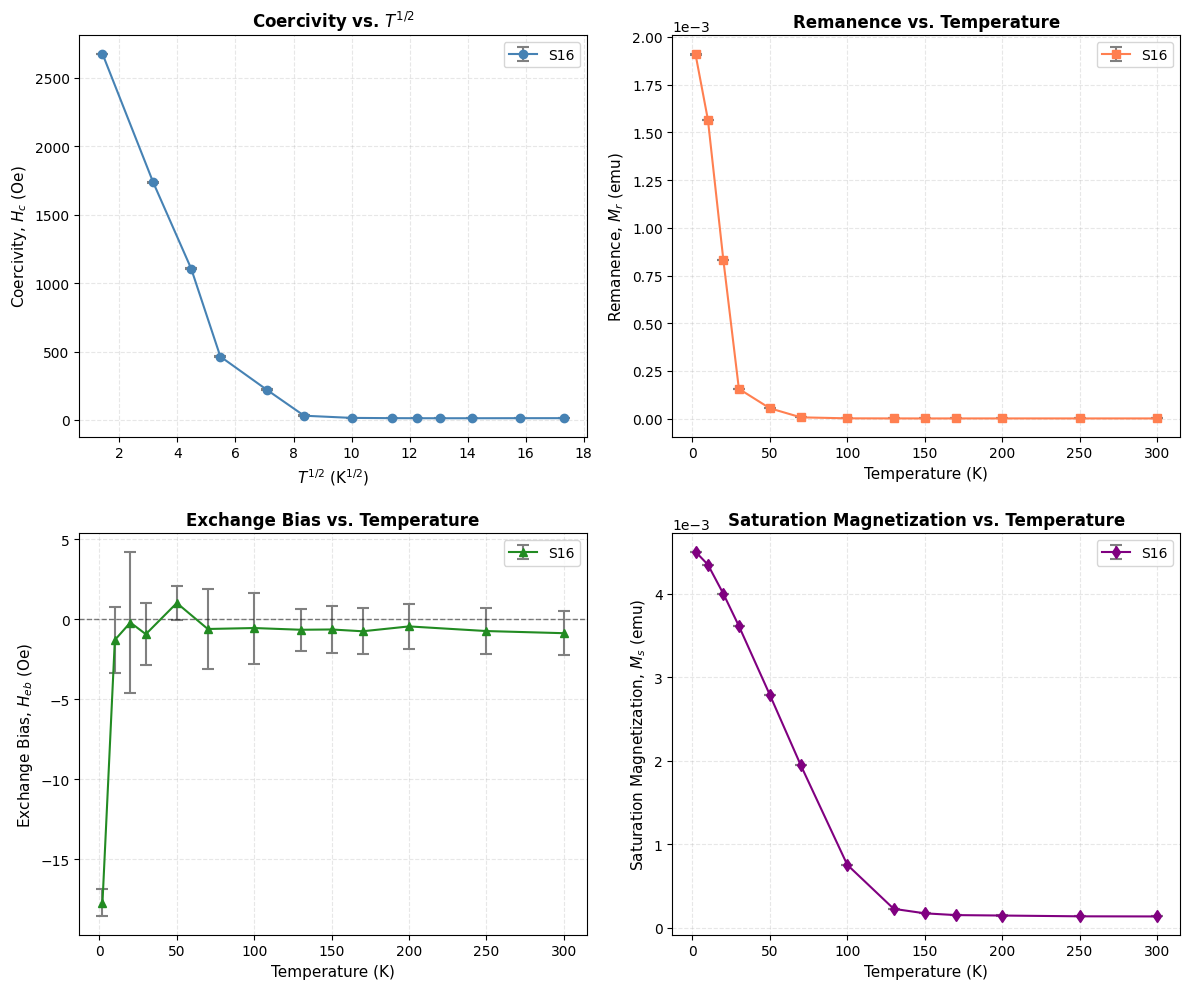


Exchange Bias (Heb):
  Non-zero bias detected: Yes

Saturation Magnetization (Ms):
  Temperature dependence: Significant


In [75]:
"""
Visualize Extracted Parameters vs. Temperature

Create multi-panel plots showing how Hc, Mr, Heb, and Ms evolve with temperature.
Error bars represent measurement uncertainty.
"""

# Filter out failed extractions
valid_params = params_df[params_df['Status'] == 'Success'].copy()

# Create 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Coercivity vs Temperature^(1/2)
ax1 = axes[0, 0]
ax1.errorbar(np.sqrt(valid_params['T_numeric']), valid_params['Hc'], 
             yerr=valid_params['Hc_std'], 
             fmt='o-', capsize=4, capthick=1.5, markersize=6, 
             color='steelblue', ecolor='gray', label='S16')
ax1.set_xlabel('$T^{1/2}$ (K$^{1/2}$)', fontsize=11)
ax1.set_ylabel('Coercivity, $H_c$ (Oe)', fontsize=11)
ax1.set_title('Coercivity vs. $T^{1/2}$', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend()

# 2. Remanence vs Temperature
ax2 = axes[0, 1]
ax2.errorbar(valid_params['T_numeric'], valid_params['Mr'], 
             yerr=valid_params['Mr_std'], 
             fmt='s-', capsize=4, capthick=1.5, markersize=6, 
             color='coral', ecolor='gray', label='S16')
ax2.set_xlabel('Temperature (K)', fontsize=11)
ax2.set_ylabel('Remanence, $M_r$ (emu)', fontsize=11)
ax2.set_title('Remanence vs. Temperature', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
ax2.legend()

# 3. Exchange Bias vs Temperature
ax3 = axes[1, 0]
ax3.errorbar(valid_params['T_numeric'], valid_params['Heb'], 
             yerr=valid_params['Heb_std'], 
             fmt='^-', capsize=4, capthick=1.5, markersize=6, 
             color='forestgreen', ecolor='gray', label='S16')
ax3.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax3.set_xlabel('Temperature (K)', fontsize=11)
ax3.set_ylabel('Exchange Bias, $H_{eb}$ (Oe)', fontsize=11)
ax3.set_title('Exchange Bias vs. Temperature', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.legend()

# 4. Saturation Magnetization vs Temperature
ax4 = axes[1, 1]
ax4.errorbar(valid_params['T_numeric'], valid_params['Ms'], 
             yerr=valid_params['Ms_std'], 
             fmt='d-', capsize=4, capthick=1.5, markersize=6, 
             color='purple', ecolor='gray', label='S16')
ax4.set_xlabel('Temperature (K)', fontsize=11)
ax4.set_ylabel('Saturation Magnetization, $M_s$ (emu)', fontsize=11)
ax4.set_title('Saturation Magnetization vs. Temperature', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
ax4.legend()

plt.tight_layout()
plt.show()


# Print summary statistics
print(f'\nExchange Bias (Heb):')
print(f'  Non-zero bias detected: {"Yes" if abs(valid_params["Heb"].mean()) > valid_params["Heb_std"].mean() else "No"}')

print(f'\nSaturation Magnetization (Ms):')
print(f'  Temperature dependence: {"Significant" if valid_params["Ms"].std()/valid_params["Ms"].mean() > 0.1 else "Weak"}')

In [76]:
# Export the extracted parameters
# export_plot_data(valid_params, 'extracted_parameters_vs_temperature')

# Uncertainty Propagation


1. **Coercivity ($H_c$) and Exchange Bias ($H_{eb}$):** These are determined by fitting a local quadratic polynomial ($H(M) = a + bM + cM^2$) to the data points near zero magnetization ($M=0$). The uncertainties are calculated as the standard error of the intercept parameter ($a$) derived from the covariance matrix of the least-squares fit.

2. **Remanence ($M_r$):** Similar to coercivity, remanence is extracted by fitting a local quadratic polynomial ($M(H) = a + bH + cH^2$) to the data points near zero field ($H=0$). The uncertainty is the standard error of the intercept parameter ($a$) from the fit's covariance matrix.

3. **Saturation Magnetization ($M_s$):** This is calculated as the mean of the absolute magnetic moments in the high-field saturation region ($|H| > 60000$ Oe). The uncertainty is estimated using the Standard Error of the Mean (SEM) of these high-field moments.